# Asset portfolio evaluation

**crc-sdk**'s fluent portfolio API turns a canonical hazard Parquet and a table of
point assets into per-asset return-period depths:

```text
HazardDataset.local(...).for_assets(...).select(...).return_periods(...).write_parquet(...)
```

1. **Assets** — three warehouses near Cologne, with sector and replacement value.
2. **Hazard** — reuse the checked-in hurdle-canonical WRI riverine fixture.
3. **Evaluate** — stream RP depths for every asset; Plotly maps and compares them.

The small fixture under `fixtures/os_climate/` keeps this notebook fully offline.


**Workflow:** [AI skill](../.agents/skills/crc-assess-asset-portfolio-risk/SKILL.md) · [Python pipeline](../pipelines/asset_portfolio_pipeline.py) · [Setup and tested versions](../ai-playbooks/docs/setup.md) · [All problems](../README.md#choose-a-problem)

### Viewing this notebook

**GitHub:** saved tables and PNG figures below show the completed run; no execution
is needed. **JupyterLab / compatible editors:** run all cells for interactive
Plotly charts with hover, zoom and pan. Each figure also includes a static PNG
fallback. Maps need internet access for basemap tiles; PMTiles downloads, where
provided, open separately in a compatible viewer.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pyarrow.parquet as pq

from crc_sdk.connectors import read_hazard_dataset
from crc_sdk.workflows import ExecutionOptions, HazardDataset, return_period_value_columns

# GitHub's notebook preview only renders static HTML/images (no JS execution),
# so every fig.show() below emits both an interactive widget (for local/Jupyter
# use) and a static PNG fallback (via kaleido) that GitHub's viewer displays.
# One MIME bundle: interactive Plotly where supported, PNG for GitHub.
pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].width = 1100
pio.renderers["png"].height = 550
pio.renderers["png"].scale = 1

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
FIXTURE_DIR = Path("../fixtures/os_climate")

LONGITUDE = 6.9603
LATITUDE = 50.9375
HAZARD_NAME = "RiverineInundation"
PATHWAY = "historical"
HORIZON = 1980
RETURN_PERIODS = [25, 50, 100, 250, 500, 1000]

HAZARD_PATH = FIXTURE_DIR / "hazard.parquet"
ASSETS_PATH = FIXTURE_DIR / "assets.parquet"
EVAL_PATH = DATA_DIR / "cologne_portfolio_evaluation.parquet"


## 1. Portfolio assets

A tiny but distinct portfolio: three points inside one source pixel so the
hazard match is unambiguous, with enough attribute variety to show passthrough
columns survive into the evaluation output.


In [2]:
assets = pq.read_table(ASSETS_PATH)
print(f"{assets.num_rows} assets <- {ASSETS_PATH}")
assets.to_pandas()


3 assets <- ../fixtures/os_climate/assets.parquet


,asset_id,longitude,latitude,sector,replacement_value
0,warehouse-a,6.96030,50.93750,logistics,12000000
1,warehouse-b,6.96031,50.93751,logistics,8500000
2,warehouse-c,6.96029,50.93749,manufacturing,21000000


## 2. Canonical hazard around the assets

The checked-in fixture retains the live ingest's canonical rows, source geometry,
curve parameters, and metadata. Reading it validates that contract before the
portfolio evaluation starts.


In [3]:
hazard = read_hazard_dataset(HAZARD_PATH)
print(f"{hazard.num_rows} canonical hazard rows <- {HAZARD_PATH}")


11 canonical hazard rows <- ../fixtures/os_climate/hazard.parquet


## 3. Evaluate return periods for every asset

`HazardDataset` is a thin facade over `LocalProvider`. `.select` filters the
canonical scenario dimensions; `.return_periods` asks for upper-tail depths;
`.write_parquet` streams the join + curve reconstruction out of core.


In [4]:
result = (
    HazardDataset.local(HAZARD_PATH)
    .for_assets(ASSETS_PATH)
    .select(
        hazard_names=[HAZARD_NAME],
        horizons=[HORIZON],
        pathways=[PATHWAY],
    )
    .return_periods(RETURN_PERIODS)
    .write_parquet(EVAL_PATH, execution=ExecutionOptions(max_workers=1))
)
evaluated = pq.read_table(EVAL_PATH).to_pandas()
print(f"evaluated rows: {result.row_count}")
print(f"value columns: {', '.join(result.value_columns)}")
evaluated


evaluated rows: 3
value columns: value_rp25, value_rp50, value_rp100, value_rp250, value_rp500, value_rp1000


,asset_id,sector,replacement_value,longitude,latitude,cell_index,hazard_name,horizon,pathway,source_id,spatial_match,value_rp25,value_rp50,value_rp100,value_rp250,value_rp500,value_rp1000
0,warehouse-c,manufacturing,21000000,6.96029,50.93749,617549611779227647,RiverineInundation,1980,historical,bfb78f711ac2e5a6d314ffacec29b9e236c730d9a6031c...,exact_geometry,1.098854,1.400417,1.701981,2.100626,2.402189,2.703752
1,warehouse-a,logistics,12000000,6.96030,50.93750,617549611779227647,RiverineInundation,1980,historical,bfb78f711ac2e5a6d314ffacec29b9e236c730d9a6031c...,exact_geometry,1.098854,1.400417,1.701981,2.100626,2.402189,2.703752
2,warehouse-b,logistics,8500000,6.96031,50.93751,617549611779227647,RiverineInundation,1980,historical,bfb78f711ac2e5a6d314ffacec29b9e236c730d9a6031c...,exact_geometry,1.098854,1.400417,1.701981,2.100626,2.402189,2.703752


## 4. Visualize


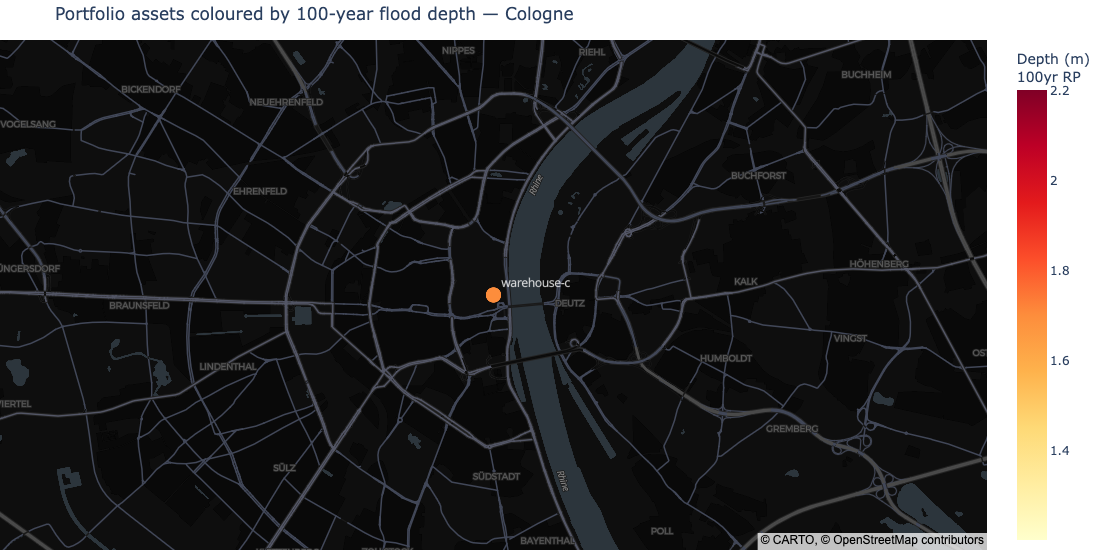

In [5]:
MAP_STYLE = "carto-darkmatter"
design_col = return_period_value_columns([100])[0]

fig_map = go.Figure(
    go.Scattermap(
        lat=evaluated["latitude"],
        lon=evaluated["longitude"],
        mode="markers+text",
        text=evaluated["asset_id"],
        textposition="top right",
        textfont=dict(color="white"),
        marker=dict(
            size=16,
            color=evaluated[design_col],
            colorscale="YlOrRd",
            colorbar_title="Depth (m)<br>100yr RP",
            showscale=True,
        ),
        customdata=np.stack(
            [evaluated["sector"], evaluated["replacement_value"], evaluated[design_col]],
            axis=-1,
        ),
        hovertemplate=(
            "%{text}<br>sector=%{customdata[0]}"
            "<br>replacement=$%{customdata[1]:,.0f}"
            "<br>100yr depth=%{customdata[2]:.3f} m<extra></extra>"
        ),
    )
)
fig_map.update_layout(
    map_style=MAP_STYLE,
    map_zoom=12,
    map_center={"lat": LATITUDE, "lon": LONGITUDE},
    margin=dict(l=0, r=0, t=40, b=0),
    title="Portfolio assets coloured by 100-year flood depth — Cologne",
)
fig_map.show()


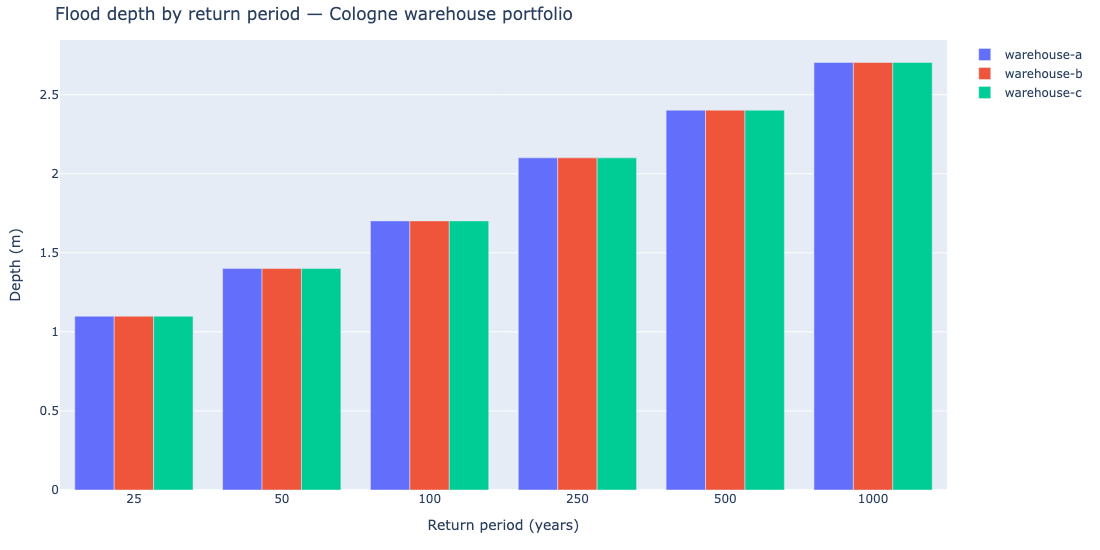

In [6]:
value_cols = list(result.value_columns)
long = evaluated.melt(
    id_vars=["asset_id"],
    value_vars=value_cols,
    var_name="rp_column",
    value_name="depth_m",
)
long["return_period"] = [int(c.split("rp")[-1]) for c in long["rp_column"]]

fig_bars = go.Figure()
for asset_id, frame in long.groupby("asset_id"):
    frame = frame.sort_values("return_period")
    fig_bars.add_trace(
        go.Bar(
            x=[str(rp) for rp in frame["return_period"]],
            y=frame["depth_m"],
            name=asset_id,
        )
    )
fig_bars.update_layout(
    barmode="group",
    title="Flood depth by return period — Cologne warehouse portfolio",
    xaxis_title="Return period (years)",
    yaxis_title="Depth (m)",
    margin=dict(l=60, r=40, t=40, b=60),
)
fig_bars.show()


## Scaling this up

[`pipelines/asset_portfolio_pipeline.py`](../pipelines/asset_portfolio_pipeline.py)
is this notebook's headless twin. Supply larger canonical hazard and asset
Parquets with `--hazard-input` / `--asset-input` and raise `--max-workers`; the
evaluator streams in bounded Arrow batches either way.
